# Yêu cầu Lab 2: Môn Học Sâu (Deep Learning)

**Bài toán:** Phân loại ảnh (Image Classification) sử dụng bộ dữ liệu CIFAR-10 (tương tự Lab 1).
**Kiến trúc mô hình:** Mạng Nơ-ron truyền thẳng đa tầng - **FCN** (Fully Connected Network) hay còn gọi là **MLP** (Multi-Layer Perceptron).

**Nhiệm vụ thực hành:**
Huấn luyện mô hình FCN/MLP với các thuật toán Tối ưu hóa (Optimizers) khác nhau. Yêu cầu chia tập dữ liệu thành đúng **10 mini-batches** (Ví dụ: Nếu tập dữ liệu có 5000 ảnh thì mỗi batch sẽ chứa 500 ảnh).

Thực hiện lần lượt các phương pháp tối ưu sau:

1. **Adam Optimizer:** - Sử dụng thuật toán Adam.
   - Cố định Learning Rate (Tốc độ học) là 10^-3.
2. **SGD with Momentum & AdamW:**
   - Sử dụng **SGD with Momentum** (Giảm dần độ dốc ngẫu nhiên có động lượng).
   - Sử dụng **AdamW** (Adam with Weight Decay) kết hợp với **Cosine Annealing** (Điều chỉnh giảm dần Learning Rate theo đồ thị hàm Cosin).
3. **Quasi-Newton Method:** - Sử dụng thuật toán tối ưu hóa bậc 2 họ Quasi-Newton (Cụ thể là thuật toán **L-BFGS**).

**Yêu cầu đầu ra:**
Tổng hợp và so sánh kết quả đánh giá (Accuracy, Precision, F1-Score...) của các Optimizers trên dưới dạng bảng số liệu.

### Setup Configuration & Data Loader (Chuẩn bị Dữ liệu)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, f1_score
import time
import warnings
from typing import Dict, Any, Optional, Tuple

# Tắt các cảnh báo zero_division của sklearn cho output clean
warnings.filterwarnings('ignore')

class Config:
    """Lưu trữ toàn bộ tham số siêu cục bộ (Hyperparameters) và cấu hình."""
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    NUM_TRAIN = 5000  # Dùng 5000 ảnh để chạy nhanh và phù hợp với L-BFGS
    NUM_TEST = 1000
    NUM_BATCHES = 10  # Yêu cầu: Chia làm đúng 10 batch
    BATCH_SIZE = NUM_TRAIN // NUM_BATCHES # => 500 ảnh/batch
    EPOCHS = 20       # Chạy 20 epochs
    
    # Loại bỏ Magic Numbers cho Model
    INPUT_DIM = 32 * 32 * 3 # CIFAR-10 ảnh 32x32 RGB
    HIDDEN_DIM = 512
    NUM_CLASSES = 10

print(f"[INFO] Using Device: {Config.DEVICE}")
print(f"[INFO] Total Train Data: {Config.NUM_TRAIN} | Batches: {Config.NUM_BATCHES} | Batch Size: {Config.BATCH_SIZE}")

[INFO] Using Device: cuda
[INFO] Total Train Data: 5000 | Number of Batches: 10 | Batch Size: 500


100%|██████████| 170M/170M [00:53<00:00, 3.20MB/s] 


## 1. Tải và Tiền xử lý dữ liệu (Data Pipeline)
Chúng ta sử dụng `torchvision` để tải bộ CIFAR-10. Dữ liệu ảnh được chuyển thành ma trận Tensor và chuẩn hóa (Normalize) về khoảng giá trị [-1, 1]. `DataLoader` được cấu hình để chia đúng số lượng batch theo yêu cầu.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(Subset(trainset, range(Config.NUM_TRAIN)), batch_size=Config.BATCH_SIZE, shuffle=True)
test_loader = DataLoader(Subset(testset, range(Config.NUM_TEST)), batch_size=Config.BATCH_SIZE, shuffle=False)

print("[INFO] DataLoaders created successfully.")

## 2. Kiến trúc Mô hình (Model Architecture)
Định nghĩa mạng FCN (Multi-Layer Perceptron).
Ma trận ảnh 3D đầu vào sẽ đi qua lớp `nn.Flatten()` để duỗi phẳng thành vector 1D trước khi đưa vào các lớp kết nối đầy đủ (`nn.Linear`). Lớp `nn.Dropout` được thêm vào để hạn chế hiện tượng quá khớp (Overfitting).

In [ ]:
class FCN_Model(nn.Module):
    def __init__(self, input_dim: int = Config.INPUT_DIM, 
                 hidden_dim: int = Config.HIDDEN_DIM, 
                 num_classes: int = Config.NUM_CLASSES):
        super(FCN_Model, self).__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),           # Activation function phi tuyến tính
            nn.Dropout(0.2),     # Chống Overfitting
            nn.Linear(hidden_dim, num_classes)
        )
        
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


[TRAINING] 1. Adam (Fixed LR)
Epoch [01/20] | Loss: 1.9718 | LR: 0.001000
Epoch [05/20] | Loss: 1.3417 | LR: 0.001000
Epoch [10/20] | Loss: 1.0047 | LR: 0.001000
Epoch [15/20] | Loss: 0.7246 | LR: 0.001000
Epoch [20/20] | Loss: 0.5037 | LR: 0.001000
[DONE] 1. Adam (Fixed LR) trained in 10.91s | Acc: 42.30%

[TRAINING] 2a. SGD + Momentum
Epoch [01/20] | Loss: 2.3078 | LR: 0.001000
Epoch [05/20] | Loss: 2.1568 | LR: 0.001000
Epoch [10/20] | Loss: 2.0475 | LR: 0.001000
Epoch [15/20] | Loss: 1.9745 | LR: 0.001000
Epoch [20/20] | Loss: 1.9135 | LR: 0.001000
[DONE] 2a. SGD + Momentum trained in 14.02s | Acc: 33.50%

[TRAINING] 2b. AdamW + Cosine LR
Epoch [01/20] | Loss: 2.0075 | LR: 0.000994
Epoch [05/20] | Loss: 1.3464 | LR: 0.000854
Epoch [10/20] | Loss: 1.0327 | LR: 0.000501
Epoch [15/20] | Loss: 0.8558 | LR: 0.000147
Epoch [20/20] | Loss: 0.8062 | LR: 0.000001
[DONE] 2b. AdamW + Cosine LR trained in 13.71s | Acc: 42.80%

[TRAINING] 3. L-BFGS (Quasi-Newton)
Epoch [01/20] | Loss: 1.7109 |

,Accuracy,Precision,F1-Score,Time (s)
Model,,,,
1. Adam (Fixed LR),0.423,0.418262,0.416181,10.91
2a. SGD + Momentum,0.335,0.303514,0.298704,14.02
2b. AdamW + Cosine LR,0.428,0.418559,0.418135,13.71
3. L-BFGS (Quasi-Newton),0.242,0.315213,0.214476,46.97


## 3. Quy trình Huấn luyện và Đánh giá (Core Pipeline)
Thay vì lặp lại code cho mỗi Optimizer, quy trình được chia thành các hàm độc lập:
* **`train_one_epoch`**: Chạy 1 vòng huấn luyện (có xử lý riêng hàm closure cho thuật toán L-BFGS).
* **`evaluate_model`**: Chạy mô hình trên tập Test và tính toán độ chính xác.
* **`run_experiment`**: Hàm quản lý chung, gọi hai hàm trên và in ra nhật ký huấn luyện (Logging).

In [ ]:
def train_one_epoch(model: nn.Module, train_loader: DataLoader, criterion: nn.Module,
                    optimizer: optim.Optimizer, scheduler: Optional[Any] = None, 
                    is_lbfgs: bool = False) -> float:
    """Chỉ chịu trách nhiệm huấn luyện mô hình trong 1 Epoch."""
    model.train()
    epoch_loss = 0.0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(Config.DEVICE), labels.to(Config.DEVICE)
        
        if is_lbfgs:
            def closure():
                optimizer.zero_grad()
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                return loss
            
            # Đã fix lỗi tính toán dư thừa ở đây
            loss = optimizer.step(closure)
            epoch_loss += loss.item()
        else:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            
    if scheduler:
        scheduler.step()
        
    return epoch_loss / len(train_loader)

def evaluate_model(model: nn.Module, test_loader: DataLoader) -> Tuple[float, float, float]:
    """Chỉ chịu trách nhiệm đánh giá mô hình."""
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(Config.DEVICE)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='macro')
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return acc, prec, f1

def run_experiment(model_name: str, model: nn.Module, optimizer: optim.Optimizer, 
                   train_loader: DataLoader, test_loader: DataLoader,
                   scheduler: Optional[Any] = None, is_lbfgs: bool = False) -> Dict[str, Any]:
    """Hàm quản lý tổng thể: Gọi Train, gọi Eval và in Logging."""
    model.to(Config.DEVICE)
    criterion = nn.CrossEntropyLoss()
    
    print(f"\n{'='*50}\n[TRAINING] {model_name}\n{'='*50}")
    start_time = time.time()
    
    for epoch in range(Config.EPOCHS):
        avg_loss = train_one_epoch(model, train_loader, criterion, optimizer, scheduler, is_lbfgs)
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            current_lr = scheduler.get_last_lr()[0] if scheduler else optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1:02d}/{Config.EPOCHS}] | Loss: {avg_loss:.4f} | LR: {current_lr:.6f}")

    train_time = time.time() - start_time
    acc, prec, f1 = evaluate_model(model, test_loader)
    
    print(f"[DONE] {model_name} trained in {train_time:.2f}s | Acc: {acc*100:.2f}%")
    
    return {
        "Model": model_name,
        "Accuracy": acc,
        "Precision": prec,
        "F1-Score": f1,
        "Time (s)": round(train_time, 2)
    }

## 4. Thực thi các kịch bản Huấn luyện
Tiến hành khởi tạo các hàm tối ưu (Optimizers) theo đúng yêu cầu bài Lab, chạy thực nghiệm và xuất báo cáo đối chiếu dưới định dạng DataFrame.

In [ ]:
results = []
LR = 1e-3

# 1. Adam Optimizer (Cố định LR)
model_adam = FCN_Model()
opt_adam = optim.Adam(model_adam.parameters(), lr=LR)
res_adam = run_experiment("1. Adam (Fixed LR)", model_adam, opt_adam, train_loader, test_loader)
results.append(res_adam)

# 2a. SGD with Momentum
model_sgd_mom = FCN_Model()
opt_sgd_mom = optim.SGD(model_sgd_mom.parameters(), lr=LR, momentum=0.9)
res_sgd = run_experiment("2a. SGD + Momentum", model_sgd_mom, opt_sgd_mom, train_loader, test_loader)
results.append(res_sgd)

# 2b. AdamW + Cosine Annealing LR
model_adamw = FCN_Model()
opt_adamw = optim.AdamW(model_adamw.parameters(), lr=LR, weight_decay=1e-2)
scheduler_cosine = optim.lr_scheduler.CosineAnnealingLR(opt_adamw, T_max=Config.EPOCHS, eta_min=1e-6)
res_adamw = run_experiment("2b. AdamW + Cosine LR", model_adamw, opt_adamw, train_loader, test_loader, scheduler=scheduler_cosine)
results.append(res_adamw)

# 3. L-BFGS (Quasi-Newton Method)
model_lbfgs = FCN_Model()
opt_lbfgs = optim.LBFGS(model_lbfgs.parameters(), lr=0.1, max_iter=20, history_size=10)
res_lbfgs = run_experiment("3. L-BFGS (Quasi-Newton)", model_lbfgs, opt_lbfgs, train_loader, test_loader, is_lbfgs=True)
results.append(res_lbfgs)

# Tổng hợp kết quả
print("\n" + "*"*60)
print("BẢNG TỔNG HỢP KẾT QUẢ ĐÁNH GIÁ CÁC OPTIMIZERS (LAB 2)")
print("*"*60)

df_results = pd.DataFrame(results)
df_results.set_index("Model", inplace=True)
display(df_results)

## 5. Trực quan hóa dự đoán
Sử dụng mô hình `AdamW` (thường cho kết quả tốt nhất trong các thực nghiệm trên) để bốc ngẫu nhiên các ảnh từ tập kiểm tra và đối chiếu nhãn dự đoán với nhãn thực tế.

Đang tải hình ảnh và dự đoán ngẫu nhiên...


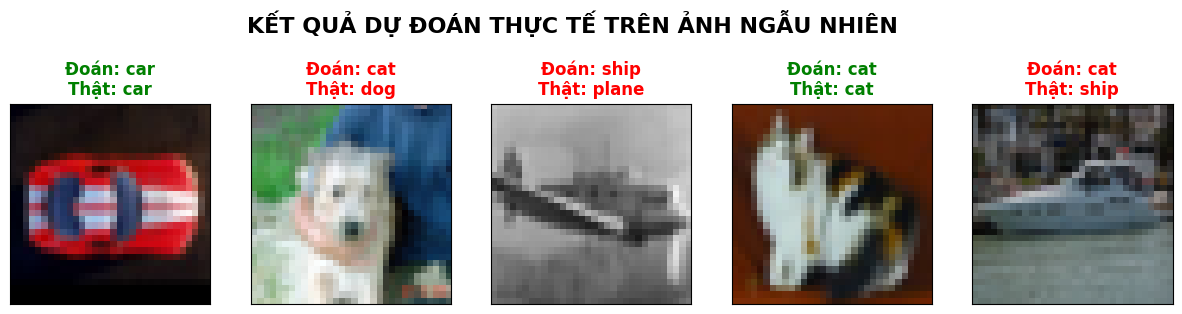

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

def imshow(img: torch.Tensor):
    img = img / 2 + 0.5     # Giải chuẩn hóa
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))

def visualize_predictions(model: nn.Module, dataloader: DataLoader, num_images: int = 5):
    model.eval()
    dataiter = iter(dataloader)
    images, labels = next(dataiter)
    
    indices = torch.randperm(images.size(0))[:num_images]
    selected_images = images[indices]
    selected_labels = labels[indices]
    
    with torch.no_grad():
        inputs = selected_images.to(Config.DEVICE)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)

    fig = plt.figure(figsize=(15, 4))
    fig.suptitle("KẾT QUẢ DỰ ĐOÁN THỰC TẾ TRÊN ẢNH NGẪU NHIÊN", fontsize=16, fontweight='bold')
    
    for idx in range(len(selected_images)):
        ax = fig.add_subplot(1, num_images, idx + 1, xticks=[], yticks=[])
        imshow(selected_images[idx].cpu())
        
        true_label = classes[selected_labels[idx]]
        pred_label = classes[predicted[idx].cpu()]
        
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"Đoán: {pred_label}\nThật: {true_label}", color=color, fontweight='bold')

    plt.show()

# Visualize bằng model_adamw
print("Đang tải hình ảnh và dự đoán ngẫu nhiên...")
visualize_predictions(model_adamw, test_loader, num_images=5)